In [1]:
# Cell 0: 環境設定與資料讀取
# 匯入必要的分析庫並讀取資料
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 設定圖表風格
sns.set_theme(
    style="whitegrid", context="paper", palette="muted"
)  # 使用 Seaborn 的預設風格
plt.rcParams["font.sans-serif"] = ["Arial"]  # 防止字型報錯
plt.rcParams["axes.unicode_minus"] = False  # 正確顯示負號

normal_file = "normal2.csv"  # 正常流量數據
attack_file = "ddos_syn_flood_lo.csv"  # DDoS 攻擊流量數據


# 讀取 Wireshark 導出的 CSV 並進行基礎清洗
def load_and_clean_data(filename):
    try:
        df = pd.read_csv(filename)
        # 強制將 Time 與 No. 轉為數值，處理可能的格式錯誤
        df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
        df["No."] = pd.to_numeric(df["No."], errors="coerce")
        # 如果 Wireshark 導出的 Length 欄位名有空格，進行處理
        if "Length" not in df.columns:
            # 嘗試尋找包含 Length 的欄位
            len_col = [c for c in df.columns if "Length" in c]
            if len_col:
                df.rename(columns={len_col: "Length"}, inplace=True)

        print(f"成功載入: {filename} | 總封包數: {len(df)}")
        return df
    except FileNotFoundError:
        print(f"File Error: 找不到檔案 {filename}，請檢查路徑。")
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None


# 定義一個函數來審核資料集的基本資訊和質量
def audit_dataset(df, name="Dataset"):
    if df is None:
        print(f"Error found in {name}: DataFrame is None（讀取失敗）")
        return

    print(f"\n==================== {name} ====================")
    print(f"Rows (packets): {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    # 顯示前五行
    print("\n Preview (First 5 rows):")
    display(df.head(5))

    # 顯示欄位型別（int/float/string）
    print("\n Data Types (dtypes):")
    display(df.dtypes)

    # 缺失值摘要
    missing = df.isna().sum()
    missing_total = int(missing.sum())
    print(f"\n Missing values (total): {missing_total:,}")
    display(missing[missing > 0].sort_values(ascending=False).to_frame("missing_count"))

    # 核心欄位檢查
    check_cols = ["No.", "Time", "Source", "Destination", "Protocol", "Length", "Info"]
    present = [c for c in check_cols if c in df.columns]
    print("\n Key columns present:", present)

    if "Time" in df.columns:
        print(f"Time range: {df['Time'].min():.6f} ~ {df['Time'].max():.6f} seconds")
    if "Length" in df.columns:
        print(
            f"Length range: {int(df['Length'].min())} ~ {int(df['Length'].max())} bytes"
        )


# 執行讀取
print("正在讀取數據...")
df_normal = load_and_clean_data(normal_file)
df_attack = load_and_clean_data(attack_file)

audit_dataset(df_normal, "Normal Traffic (Baseline)")
audit_dataset(df_attack, "Attack Traffic (SYN Flood)")

正在讀取數據...
成功載入: normal2.csv | 總封包數: 8028
成功載入: ddos_syn_flood_lo.csv | 總封包數: 2320270

==================== Normal Traffic (Baseline) ====================
Rows (packets): 8,028
Columns: 7

 Preview (First 5 rows):


,No.,Time,Source,Destination,Protocol,Length,Info
0,1,0.000000,192.168.43.128,192.168.43.2,DNS,98,Standard query 0x180a HTTPS rr5---sn-ipoxu-u2x...
1,2,0.000067,192.168.43.128,192.168.43.2,DNS,98,Standard query 0x0733 A rr5---sn-ipoxu-u2xee.g...
2,3,0.000068,192.168.43.128,192.168.43.2,DNS,98,Standard query 0x0c32 AAAA rr5---sn-ipoxu-u2xe...
3,4,0.007841,192.168.43.2,192.168.43.128,DNS,147,Standard query response 0x0733 A rr5---sn-ipox...
4,5,0.012024,192.168.43.2,192.168.43.128,DNS,159,Standard query response 0x0c32 AAAA rr5---sn-i...



 Data Types (dtypes):


No.              int64
Time           float64
Source          object
Destination     object
Protocol        object
Length           int64
Info            object
dtype: object


 Missing values (total): 0


...


 Data Types (dtypes):


No.              int64
Time           float64
Source          object
Destination     object
Protocol        object
Length           int64
Info            object
dtype: object


 Missing values (total): 0


,missing_count



 Key columns present: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']
Time range: 0.000000 ~ 4.735496 seconds
Length range: 54 ~ 54 bytes


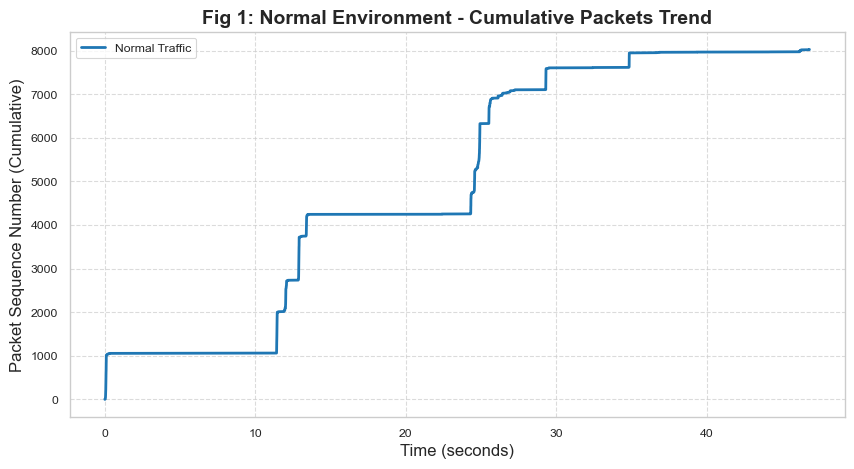

In [2]:
# Cell 1: 圖 1 (基礎要求 - 正常流量趨勢)
# 分析：正常環境下，封包累積呈現線性且緩慢的增長
plt.figure(figsize=(10, 5))

if df_normal is not None:

    plt.plot(
        df_normal["Time"],
        df_normal["No."],
        color="#1f77b4",
        linewidth=2,
        label="Normal Traffic",
    )

    plt.title(
        "Fig 1: Normal Environment - Cumulative Packets Trend",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Time (seconds)", fontsize=12)
    plt.ylabel("Packet Sequence Number (Cumulative)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()
else:
    print("無法繪圖：正常流量資料未載入成功")

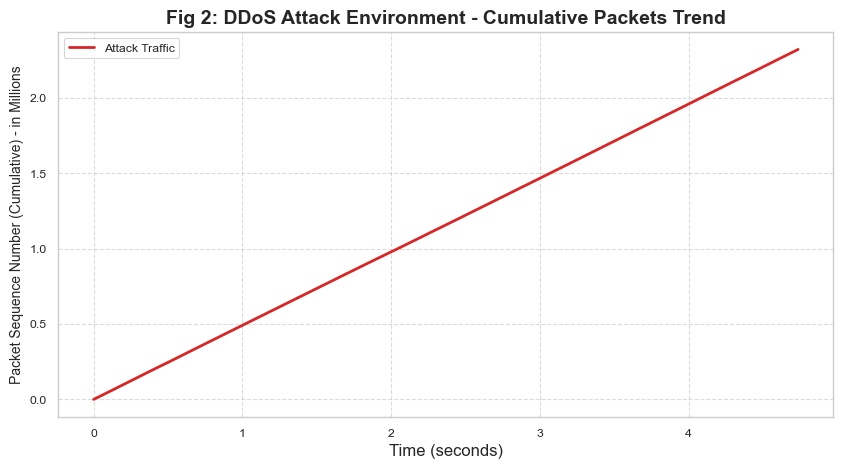

In [3]:
# Cell 2: 圖 2 (基礎要求 - 攻擊流量趨勢)
# 分析：攻擊環境下，短時間內封包數量暴增，斜率極高，顯示流量型攻擊特徵
plt.figure(figsize=(10, 5))

if df_attack is not None:

    plt.plot(
        df_attack["Time"],
        df_attack["No."] / 1_000_000,
        color="#d62728",
        linewidth=2,
        label="Attack Traffic",
    )

    plt.title(
        "Fig 2: DDoS Attack Environment - Cumulative Packets Trend",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Time (seconds)", fontsize=12)
    plt.ylabel("Packet Sequence Number (Cumulative) - in Millions", fontsize=10)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()
else:
    print("無法繪圖：攻擊流量資料未載入成功")

C:\Users\kenny\AppData\Local\Temp\ipykernel_18644\1556646494.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_l4.groupby(["TimeBin", "L4_Group"])


<Figure size 1200x500 with 0 Axes>

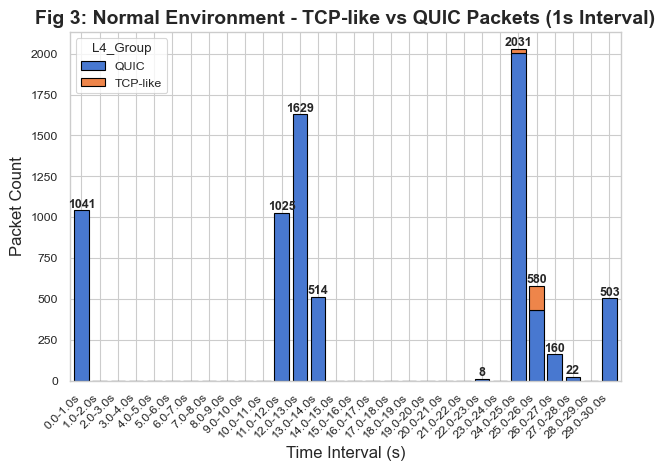

In [7]:
# Cell 3: 圖 3 (TCP-like vs QUIC 封包分佈)
# 分析： 分析「正常環境」下傳輸層流量的時間分佈特徵，並比較 TCP-like 協定（包含 HTTP/TLS 等跑在 TCP 上的上層協定）與 QUIC 協定的封包數量差異。
plt.figure(figsize=(12, 5))

if df_normal is not None:
    # 清理字串前後空白，確保一致性
    p = df_normal["Protocol"].astype(str).str.strip()

    # 把「看起來跑在 TCP 上的上層協定」也算進 TCP-like
    tcp_like_keywords = ["TCP", "TLS", "SSL", "HTTP", "HTTP2", "HTTP/2", "OCSP"]
    # QUIC 通常會直接顯示 QUIC（有些版本會顯示 GQUIC）
    quic_keywords = ["QUIC", "GQUIC"]

    is_tcp_like = p.str.upper().apply(
        lambda s: any(k in s for k in [k.upper() for k in tcp_like_keywords])
    )
    is_quic = p.str.upper().apply(
        lambda s: any(k in s for k in [k.upper() for k in quic_keywords])
    )

    # 只取 TCP-like + QUIC
    df_l4 = df_normal[is_tcp_like | is_quic].copy()

    if df_l4.empty:
        print("Fig3: 未偵測到 TCP-like / QUIC 封包，請確認是否成功捕獲瀏覽流量。")
    else:
        # 顯示拆分（TCP-like vs QUIC）
        df_l4["L4_Group"] = np.where(is_quic.loc[df_l4.index], "QUIC", "TCP-like")

        # bins：每 1 秒（至少涵蓋前 6 秒）
        max_time = df_l4["Time"].max()
        bins = np.arange(0, max(6.0, max_time + 1), 1)  # 1秒間隔，確保至少有6秒的區間

        # 每個區間、每種類別計數
        df_l4["TimeBin"] = pd.cut(df_l4["Time"], bins=bins)
        pivot = (
            df_l4.groupby(["TimeBin", "L4_Group"])
            .size()
            .unstack(fill_value=0)
            .sort_index()
        )

        #  30 個區間（0~30秒）
        pivot_head = pivot.head(30)

        # 堆疊柱狀圖
        ax = pivot_head.plot(kind="bar", stacked=True, width=0.8, edgecolor="black")

        plt.title(
            "Fig 3: Normal Environment - TCP-like vs QUIC Packets (1s Interval)",
            fontsize=14,
            fontweight="bold",
        )
        plt.xlabel("Time Interval (s)", fontsize=12)
        plt.ylabel("Packet Count", fontsize=12)

        labels = [f"{b.left:.1f}-{b.right:.1f}s" for b in pivot_head.index]
        plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha="right")

        # 在每個柱子最上方標總數
        totals = pivot_head.sum(axis=1).values
        for i, v in enumerate(totals):
            if v > 0:
                ax.text(
                    i,
                    v,
                    str(int(v)),
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold",
                )

        plt.tight_layout()
        plt.show()
else:
    print(
        "Packets not found：正常流量檔案中未檢測到 TCP/QUIC 封包，請確認 Wireshark 捕獲時是否有訪問網頁。"
    )

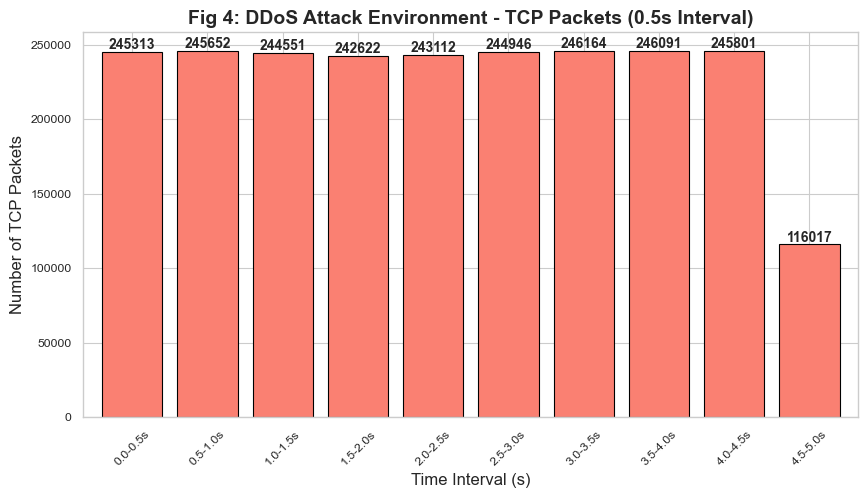

In [ ]:
# Cell 4: 圖 4 (基礎要求 - 攻擊 TCP 分佈)
# 分析：攻擊期間，每個時間區間都充滿大量 TCP 封包，證實 SYN Flood 造成資源耗盡
plt.figure(figsize=(10, 5))

if df_attack is not None:
    # 篩選 TCP 協定
    tcp_attack = df_attack[df_attack["Protocol"] == "TCP"]

    if not tcp_attack.empty:
        max_time = df_attack["Time"].max()
        # 確保 bins 至少能涵蓋前幾秒，並且不會過多導致圖表擁擠
        bins = np.arange(0, max(4.0, max_time + 1), 0.5)
        # 統計每個區間的封包數 (0.5秒為一個區間)
        time_groups = pd.cut(tcp_attack["Time"], bins=bins)
        counts = time_groups.value_counts().sort_index()

        # 取前 10 個區間 (0-5秒)
        ax = counts.head(10).plot(
            kind="bar", color="salmon", edgecolor="black", width=0.8
        )

        plt.title(
            "Fig 4: DDoS Attack Environment - TCP Packets (0.5s Interval)",
            fontsize=14,
            fontweight="bold",
        )
        plt.xlabel("Time Interval (s)", fontsize=12)
        plt.ylabel("Number of TCP Packets", fontsize=12)

        labels = [f"{b.left:.1f}-{b.right:.1f}s" for b in counts.head(10).index]
        plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)

        # 標示數值 (顯示數量級差異)
        for i, v in enumerate(counts.head(10)):
            ax.text(
                i, v, str(v), ha="center", va="bottom", fontsize=10, fontweight="bold"
            )

        plt.show()
    else:
        print(
            "Packets not found：攻擊流量檔案中未檢測到 TCP 封包，請確認 Wireshark 捕獲時是否有 SYN Flood 攻擊行為。"
        )

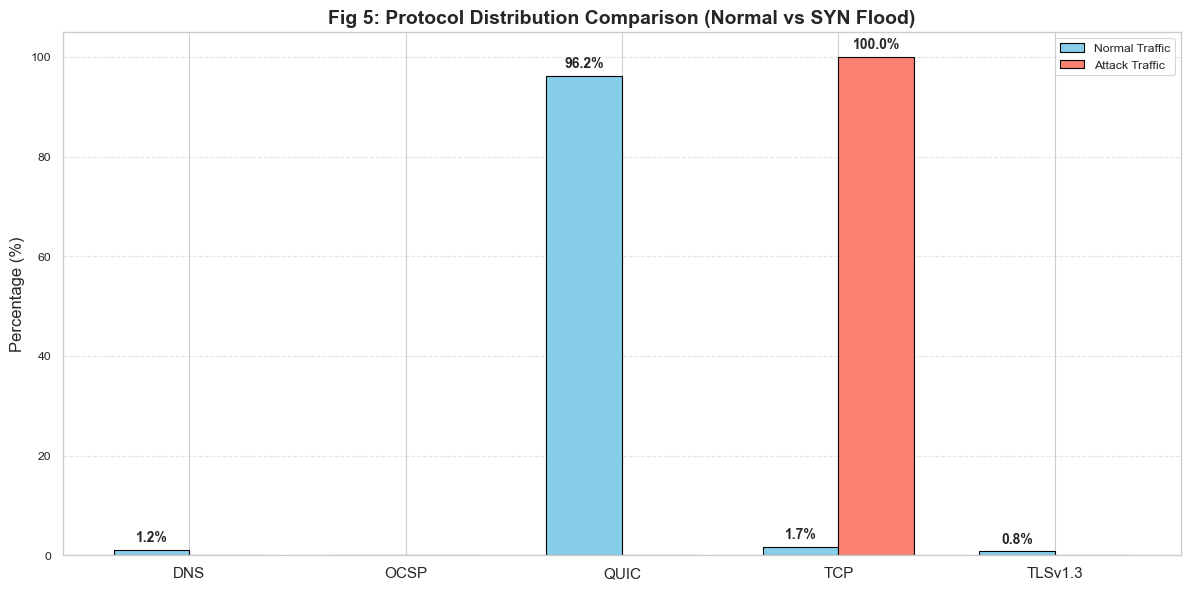

In [ ]:
# Cell 5: 進階分析 A (協定佔比 - 證明攻擊特徵)
# 分析：正常流量中 HTTP/TCP 佔比高，攻擊流量中 TCP 佔比極高，反映 SYN Flood 攻擊特徵
plt.figure(figsize=(12, 6))

if df_normal is not None and df_attack is not None:
    # 計算協定百分比 (使用 value_counts(normalize=True) * 100)
    # 取前 5 個最常出現的協定，避免圖表太長
    top_n = 5

    # 為了確保對比基準一致，我們取兩者聯集的前幾大協定
    # 先計算百分比
    norm_counts = df_normal["Protocol"].value_counts(normalize=True) * 100
    attack_counts = df_attack["Protocol"].value_counts(normalize=True) * 100

    # 找出雙方最主要的協定 (聯集)
    top_protocols = list(
        set(norm_counts.head(top_n).index) | set(attack_counts.head(top_n).index)
    )
    top_protocols.sort()  # 排序讓圖表整齊

    # 準備繪圖數據 (若某個協定在該數據集不存在，則填 0)
    normal_vals = [norm_counts.get(p, 0) for p in top_protocols]
    attack_vals = [attack_counts.get(p, 0) for p in top_protocols]

    # 設定柱狀圖位置
    x = np.arange(len(top_protocols))  # 標籤位置
    width = 0.35  # 柱子寬度

    # 繪圖 (Normal 用藍色系，Attack 用紅色系/Salmon)
    rects1 = plt.bar(
        x - width / 2,
        normal_vals,
        width,
        label="Normal Traffic",
        color="skyblue",
        edgecolor="black",
    )
    rects2 = plt.bar(
        x + width / 2,
        attack_vals,
        width,
        label="Attack Traffic",
        color="salmon",
        edgecolor="black",
    )

    # 設定標籤與標題
    plt.ylabel("Percentage (%)", fontsize=12)
    plt.title(
        "Fig 5: Protocol Distribution Comparison (Normal vs SYN Flood)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xticks(x, top_protocols, fontsize=11)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)  # 只畫橫向網格，比較乾淨

    # 自動標註數值 (使用 Cell 4 的邏輯：ax.text)
    # 定義一個標註函數，讓程式碼更整潔
    def autolabel(rects):
        # 在每個柱子上方標示高度數值
        for rect in rects:
            height = rect.get_height()
            # 只標示大於 1% 的數值，避免 0% 擠在一起太亂
            if height > 0.5:
                plt.text(
                    rect.get_x() + rect.get_width() / 2.0,
                    height + 1,
                    f"{height:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    fontweight="bold",
                )

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()
else:
    print("無法繪圖：資料未載入成功")

C:\Users\kenny\AppData\Local\Temp\ipykernel_5248\2658374017.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.barplot(x=['Normal Traffic', 'Attack Traffic'], y=[unique_normal, unique_attack], palette=['#4c72b0', '#c44e52'])


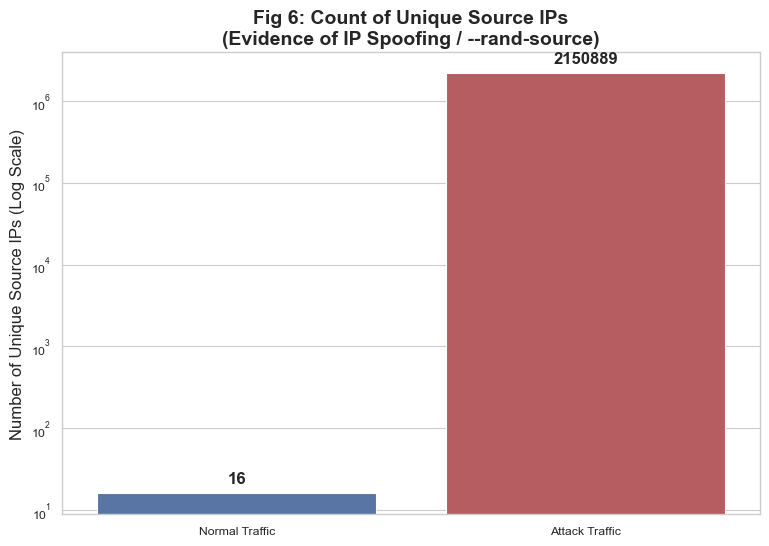

In [ ]:
# Cell 6: 進階分析 B (IP 欺騙證據)
# 分析：對比正常與攻擊流量的「唯一來源 IP 數量」。攻擊流量 IP 數暴增，證明使用了 --rand-source 進行 IP 欺騙。
plt.figure(figsize=(9, 6))

if df_normal is not None and df_attack is not None:
    # 計算 Unique Source IPs 數量
    unique_normal = df_normal["Source"].nunique()
    unique_attack = df_attack["Source"].nunique()

    # 繪製柱狀圖
    bp = sns.barplot(
        x=["Normal Traffic", "Attack Traffic"],
        y=[unique_normal, unique_attack],
        palette=["#4c72b0", "#c44e52"],
    )

    plt.title(
        "Fig 6: Count of Unique Source IPs\n(Evidence of IP Spoofing / --rand-source)",
        fontsize=14,
        fontweight="bold",
    )
    plt.ylabel("Number of Unique Source IPs (Log Scale)", fontsize=12)

    # 設定對數刻度，因為攻擊 IP 數量通常是正常的數百倍，用 log 才能看清
    plt.yscale("log")

    # 在柱子上標註具體數字
    for p in bp.patches:
        bp.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=12,
            fontweight="bold",
        )

    plt.show()
else:
    print("無法繪圖：資料未載入成功")

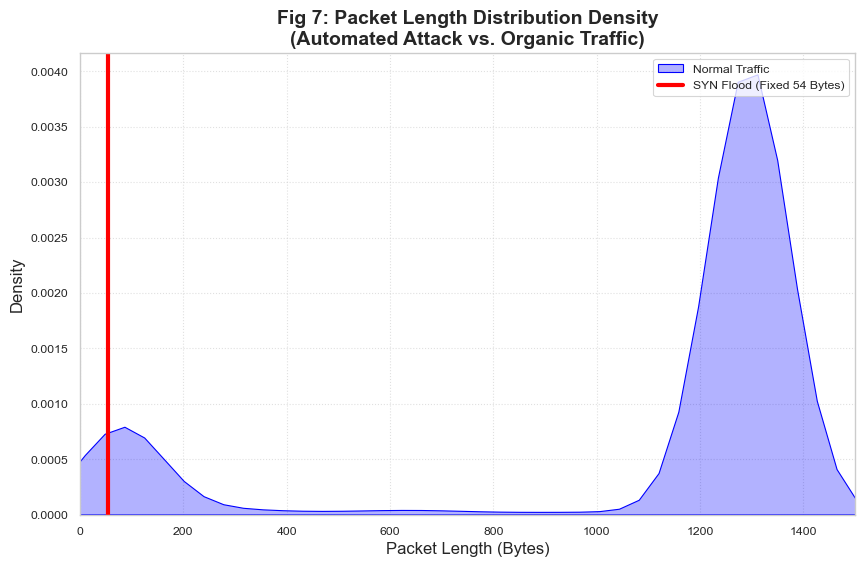

In [ ]:
# Cell 7: 進階分析 C (封包大小特徵 - 自動化攻擊證據)
# 分析：攻擊流量在特定封包大小 (如 54/60 bytes) 出現極高尖峰，證明是 hping3 自動生成的無 Payload 封包。
plt.figure(figsize=(10, 6))

if df_normal is not None and df_attack is not None and "Length" in df_normal.columns:

    # 使用 fill=True 來填充密度曲線下方，alpha 調整透明度以便重疊比較
    sns.kdeplot(
        df_normal["Length"], fill=True, label="Normal Traffic", color="blue", alpha=0.3
    )

    # Attack 固定值畫 vertical spike (因為攻擊封包大小固定，所以用垂直線表示)
    attack_len = df_attack["Length"].iloc[0]
    plt.axvline(
        attack_len, color="red", linewidth=3, label="SYN Flood (Fixed 54 Bytes)"
    )

    plt.title(
        "Fig 7: Packet Length Distribution Density\n(Automated Attack vs. Organic Traffic)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Packet Length (Bytes)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.xlim(0, 1500)  # 限制在乙太網 MTU 範圍內
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)

    plt.show()
else:
    print("無法繪製封包長度分佈：請確認 CSV 檔案中包含 'Length' 欄位。")

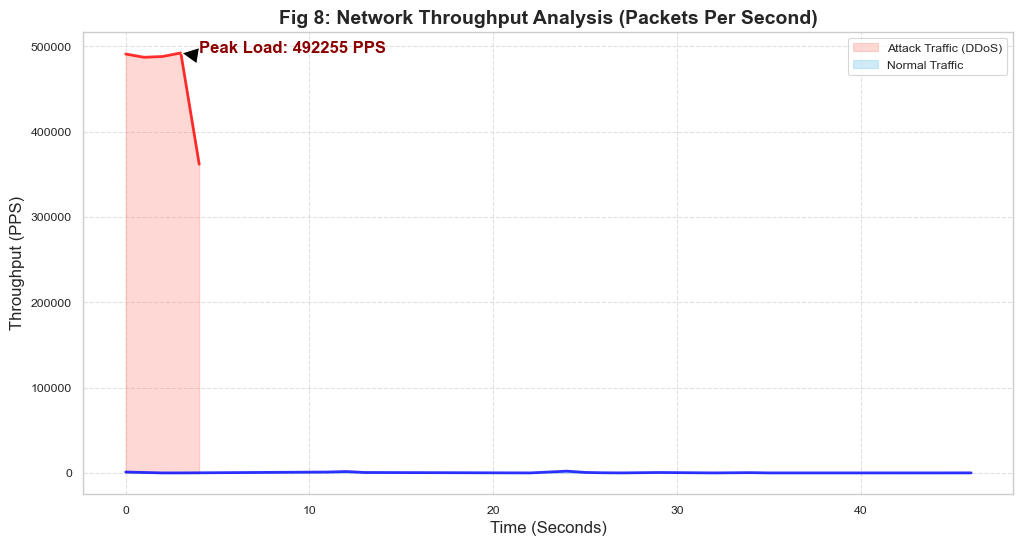

In [ ]:
# Cell 8: 進階分析 D (吞吐量分析)
# 分析：攻擊期間每秒封包數暴增，顯示 SYN Flood 對網路頻寬的瞬間壓迫力
plt.figure(figsize=(12, 6))

# 檢查資料是否存在
if df_normal is not None and df_attack is not None:

    # 資料處理：計算每秒封包數 (PPS)
    # 將時間轉為整數 (秒)，並統計每秒出現次數
    df_normal["Second"] = df_normal["Time"].astype(int)
    df_attack["Second"] = df_attack["Time"].astype(int)

    pps_normal = df_normal["Second"].value_counts().sort_index()
    pps_attack = df_attack["Second"].value_counts().sort_index()

    # 繪圖：使用區域圖 (Fill Between) 增強視覺衝擊力
    # 攻擊流量 (紅色)
    plt.fill_between(
        pps_attack.index,
        pps_attack.values,
        color="salmon",
        alpha=0.3,
        label="Attack Traffic (DDoS)",
    )
    plt.plot(pps_attack.index, pps_attack.values, color="red", alpha=0.8, linewidth=2)

    # 正常流量 (藍色)
    plt.fill_between(
        pps_normal.index,
        pps_normal.values,
        color="skyblue",
        alpha=0.4,
        label="Normal Traffic",
    )
    plt.plot(pps_normal.index, pps_normal.values, color="blue", alpha=0.8, linewidth=2)

    # 設定標題與座標軸
    plt.title(
        "Fig 8: Network Throughput Analysis (Packets Per Second)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Time (Seconds)", fontsize=12)
    plt.ylabel("Throughput (PPS)", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.6)

    # 標註峰值 (Peak Annotation)
    if not pps_attack.empty:
        max_pps = pps_attack.max()
        max_time = pps_attack.idxmax()

        plt.annotate(
            f"Peak Load: {max_pps} PPS",
            xy=(max_time, max_pps),
            xytext=(max_time + 1, max_pps),
            arrowprops=dict(facecolor="black", shrink=0.05),
            fontsize=12,
            fontweight="bold",
            color="darkred",
        )

    plt.show()
else:
    print("無法繪圖：資料未載入成功")

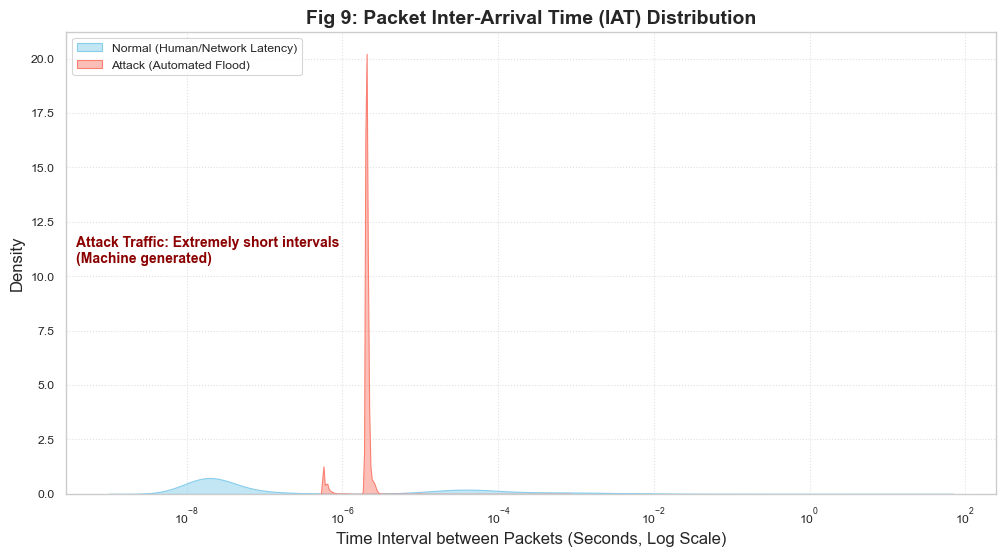

In [ ]:
# Cell 9: 進階分析 E (封包間隔時間分佈 - 自動化攻擊證據)
# 分析：攻擊流量的封包間隔時間 (IAT) 極短且集中在毫秒級，反映自動化工具的高速封包生成特徵；正常流量則分佈較廣，反映人為操作和網路延遲的自然變異。
plt.figure(figsize=(12, 6))

# 檢查資料是否存在
if df_normal is not None and df_attack is not None:

    # 資料處理：計算 IAT (當前封包時間 - 上一個封包時間)
    # dropna() 去除第一個無法計算差值的 NaN
    iat_normal = df_normal["Time"].diff().dropna()
    iat_attack = df_attack["Time"].diff().dropna()

    # 檢查是否有足夠數據繪圖
    if len(iat_normal) > 1 and len(iat_attack) > 1:

        # 繪圖：使用 KDE 密度圖 (Kernel Density Estimation)
        # log_scale=True 是關鍵，因為攻擊間隔通常是微秒級，正常是秒級，級距差太大
        sns.kdeplot(
            iat_normal,
            fill=True,
            color="skyblue",
            label="Normal (Human/Network Latency)",
            log_scale=True,
            alpha=0.5,
        )
        sns.kdeplot(
            iat_attack,
            fill=True,
            color="salmon",
            label="Attack (Automated Flood)",
            log_scale=True,
            alpha=0.5,
        )

        # 設定標題與座標軸
        plt.title(
            "Fig 9: Packet Inter-Arrival Time (IAT) Distribution",
            fontsize=14,
            fontweight="bold",
        )
        plt.xlabel("Time Interval between Packets (Seconds, Log Scale)", fontsize=12)
        plt.ylabel("Density", fontsize=12)
        plt.legend(loc="upper left")  # 圖例放左上避免擋住圖形
        plt.grid(True, linestyle=":", alpha=0.6)

        # 註解說明 
        plt.text(
            0.01,
            0.5,
            "Attack Traffic: Extremely short intervals\n(Machine generated)",
            transform=plt.gca().transAxes,
            fontsize=10,
            color="darkred",
            fontweight="bold",
        )

        plt.show()
    else:
        print("數據不足，無法繪製 IAT 分佈圖 (需要至少 2 個封包)")
else:
    print("無法繪圖：資料未載入成功")